<a href="https://colab.research.google.com/github/011010110100/fase2-businness-inteligence/blob/main/Fase2_BI_Hotel_Bookings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Business Intelligence e Analytics – Cancelamento de Reservas Hoteleiras

## Cancelamento de Reservas Hoteleiras

## 1. Apresentação do Projeto

Data set que será utilizado -> hotel_booking.csv, estará disponível no github também.

## 2. Configuração do Ambiente

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## 3. Carregamento dos Dados

In [ ]:
#  Nesta etapa, o conjunto de dados Hotel Booking Demand é carregado a partir do Google Drive para realização das etapas de preparação, análise e modelagem.

caminho_arquivo = './hotel_bookings.csv'
df = pd.read_csv(caminho_arquivo)


print(f'Quantidade de linhas: {df.shape[0]}')
print(f'Quantidade de colunas: {df.shape[1]}')
df.head()

Quantidade de linhas: 119390
Quantidade de colunas: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 4. Compreensão Inicial dos Dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


## 5. Seleção das Variáveis

In [ ]:
df['hotel'].value_counts()

,count
hotel,
City Hotel,79330
Resort Hotel,40060


In [ ]:
df['hotel'].value_counts(normalize=True) * 100
# para termos a ideia percentual

,proportion
hotel,
City Hotel,66.446101
Resort Hotel,33.553899


In [ ]:
df['is_canceled'].value_counts()

,count
is_canceled,
0,75166
1,44224


In [ ]:
df['is_canceled'].value_counts(normalize=True) * 100
# 0 = reserva não cancelada
# 1 = reserva cancelada

,proportion
is_canceled,
0,62.958372
1,37.041628


In [ ]:
df['is_repeated_guest'].value_counts()
df['is_repeated_guest'].value_counts(normalize=True) * 100

,proportion
is_repeated_guest,
0,96.808778
1,3.191222


In [ ]:
df['lead_time'].describe()

,lead_time
count,119390.000000
mean,104.011416
std,106.863097
min,0.000000
25%,18.000000
50%,69.000000
75%,160.000000
max,737.000000


### Resumo da compreensão inicial

Nesta etapa foram verificadas as dimensões do conjunto de dados, os tipos das variáveis, suas principais estatísticas e a distribuição das variáveis relacionadas ao problema estudado. A análise inicial permitiu compreender a estrutura da base antes das etapas de avaliação da qualidade, limpeza e transformação dos dados.

## 6. Avaliação da Qualidade dos Dados

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
company,112593
agent,16340
country,488
children,4
arrival_date_month,0
arrival_date_week_number,0
hotel,0
is_canceled,0
stays_in_weekend_nights,0
arrival_date_day_of_month,0


In [ ]:
valores_ausentes = pd.DataFrame({
    'Quantidade': df.isnull().sum(),
    'Percentual (%)': (df.isnull().sum() / len(df)) * 100
})

valores_ausentes = valores_ausentes[valores_ausentes['Quantidade'] > 0]
valores_ausentes.sort_values('Quantidade', ascending=False)

,Quantidade,Percentual (%)
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


In [ ]:
duplicados = df.duplicated().sum()

print(f'Quantidade de registros duplicados: {duplicados}')

percentual_duplicados = (duplicados / len(df)) * 100

print(f'Percentual de registros duplicados: {percentual_duplicados:.2f}%')

Quantidade de registros duplicados: 31994
Percentual de registros duplicados: 26.80%


In [ ]:
print('is_canceled:')
print(df['is_canceled'].value_counts(dropna=False))

print('\nis_repeated_guest:')
print(df['is_repeated_guest'].value_counts(dropna=False))

is_canceled:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

is_repeated_guest:
is_repeated_guest
0    115580
1      3810
Name: count, dtype: int64


In [ ]:
total_hospedes = (
    df['adults'].fillna(0) +
    df['children'].fillna(0) +
    df['babies'].fillna(0)
)

reservas_sem_hospedes = (total_hospedes == 0).sum()

print(f'Reservas sem hóspedes: {reservas_sem_hospedes}')

df[total_hospedes == 0][
    ['adults', 'children', 'babies', 'hotel', 'is_canceled']
].head()
# como existem, o que faremos na limpeza dos dados? remover esses casos?

Reservas sem hóspedes: 180


,adults,children,babies,hotel,is_canceled
2224,0,0.0,0,Resort Hotel,0
2409,0,0.0,0,Resort Hotel,0
3181,0,0.0,0,Resort Hotel,0
3684,0,0.0,0,Resort Hotel,0
3708,0,0.0,0,Resort Hotel,0


In [ ]:
colunas_categoricas = [
    'hotel',
    'arrival_date_month',
    'market_segment',
    'distribution_channel',
    'deposit_type',
    'customer_type'
]

for coluna in colunas_categoricas:
    print(f'\n--- {coluna} ---')
    print(df[coluna].value_counts(dropna=False))


--- hotel ---
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

--- arrival_date_month ---
arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64

--- market_segment ---
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

--- distribution_channel ---
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

--- deposit_type ---
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

--- customer_type ---
customer_type
Transient          89613
T

In [ ]:
print('Anos:')
print(sorted(df['arrival_date_year'].unique()))

print('\nDias:')
print(df['arrival_date_day_of_month'].min(),
      df['arrival_date_day_of_month'].max())

print('\nMeses:')
print(df['arrival_date_month'].unique())

Anos:
[np.int64(2015), np.int64(2016), np.int64(2017)]

Dias:
1 31

Meses:
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']


In [ ]:
df[['lead_time', 'adr']].describe()

,lead_time,adr
count,119390.000000,119390.000000
mean,104.011416,101.831122
std,106.863097,50.535790
min,0.000000,-6.380000
25%,18.000000,69.290000
50%,69.000000,94.575000
75%,160.000000,126.000000
max,737.000000,5400.000000


In [ ]:
df[['lead_time', 'adr']].quantile([0.01, 0.25, 0.50, 0.75, 0.99])

,lead_time,adr
0.01,0.0,0.000
0.25,18.0,69.290
0.50,69.0,94.575
0.75,160.0,126.000
0.99,444.0,252.000


In [ ]:
print('--- RESUMO DA QUALIDADE DOS DADOS ---')
print(f'Registros: {len(df)}')
print(f'Colunas: {df.shape[1]}')
print(f'Valores ausentes: {df.isnull().sum().sum()}')
print(f'Registros duplicados: {df.duplicated().sum()}')
print(f'Reservas sem hóspedes: {(total_hospedes == 0).sum()}')

--- RESUMO DA QUALIDADE DOS DADOS ---
Registros: 119390
Colunas: 32
Valores ausentes: 129425
Registros duplicados: 31994
Reservas sem hóspedes: 180


### Resumo da avaliação da qualidade

Foram analisados valores ausentes, possíveis registros duplicados,
consistência das principais variáveis, valores numéricos suspeitos,
categorias existentes e possíveis valores discrepantes.

Nesta etapa os problemas foram apenas identificados. As decisões de
tratamento serão realizadas na etapa de limpeza dos dados, considerando
o contexto de cada variável e sua relevância para as análises.

## 7. Limpeza dos Dados

A limpeza dos dados foi realizada considerando os problemas identificados
na etapa de avaliação da qualidade. Foram tratados valores ausentes na
variável children e removidos registros considerados inconsistentes.

In [ ]:
df_limpo = df.copy()

# Preencher os valores ausentes de crianças com zero
df_limpo['children'] = df_limpo['children'].fillna(0)

# Remover reservas sem hóspedes
df_limpo = df_limpo[
    (df_limpo['adults'] + df_limpo['children'] + df_limpo['babies']) > 0
]

# Remover registros com ADR negativo
df_limpo = df_limpo[df_limpo['adr'] >= 0]

# Reorganizar o índice
df_limpo = df_limpo.reset_index(drop=True)

In [ ]:
print(f'Registros antes da limpeza: {len(df)}')
print(f'Registros depois da limpeza: {len(df_limpo)}')
print(f'Registros removidos: {len(df) - len(df_limpo)}')

Registros antes da limpeza: 119390
Registros depois da limpeza: 119209
Registros removidos: 181


## 8. Transformação dos Dados

Nesta etapa foram criadas variáveis derivadas para facilitar as análises.
Foi criada uma data completa de chegada e uma categorização da antecedência
das reservas em faixas de lead time.

In [ ]:
# Criar data completa de chegada
df_limpo['arrival_date'] = pd.to_datetime(
    df_limpo['arrival_date_year'].astype(str) + '-' +
    df_limpo['arrival_date_month'] + '-' +
    df_limpo['arrival_date_day_of_month'].astype(str)
)

In [ ]:
df_limpo[['arrival_date_year',
          'arrival_date_month',
          'arrival_date_day_of_month',
          'arrival_date']].head()

,arrival_date_year,arrival_date_month,arrival_date_day_of_month,arrival_date
0,2015,July,1,2015-07-01
1,2015,July,1,2015-07-01
2,2015,July,1,2015-07-01
3,2015,July,1,2015-07-01
4,2015,July,1,2015-07-01


In [ ]:
df_limpo['lead_time_faixa'] = pd.cut(
    df_limpo['lead_time'],
    bins=[-1, 30, 90, 180, float('inf')],
    labels=[
        '0-30 dias',
        '31-90 dias',
        '91-180 dias',
        'Mais de 180 dias'
    ]
)

In [ ]:
df_limpo[['lead_time', 'lead_time_faixa']].head(10)

,lead_time,lead_time_faixa
0,342,Mais de 180 dias
1,737,Mais de 180 dias
2,7,0-30 dias
3,13,0-30 dias
4,14,0-30 dias
5,14,0-30 dias
6,0,0-30 dias
7,9,0-30 dias
8,85,31-90 dias
9,75,31-90 dias


In [ ]:
df_limpo['lead_time_faixa'].value_counts().sort_index()

,count
lead_time_faixa,
0-30 dias,38580
31-90 dias,29529
91-180 dias,26420
Mais de 180 dias,24680


In [ ]:
df_limpo[
    ['arrival_date', 'lead_time', 'lead_time_faixa', 'is_canceled']
].head()

,arrival_date,lead_time,lead_time_faixa,is_canceled
0,2015-07-01,342,Mais de 180 dias,0
1,2015-07-01,737,Mais de 180 dias,0
2,2015-07-01,7,0-30 dias,0
3,2015-07-01,13,0-30 dias,0
4,2015-07-01,14,0-30 dias,0


## 9. Validação da Base Tratada

Nesta etapa foi realizada uma verificação final da base após os procedimentos
de limpeza e transformação, garantindo que os principais problemas identificados
tenham sido tratados antes da exportação dos dados.

In [ ]:
print("=== VALIDAÇÃO DA BASE TRATADA ===")

print(f"\nQuantidade de registros: {len(df_limpo)}")

print("\nValores ausentes em children:")
print(df_limpo['children'].isnull().sum())

print("\nReservas sem hóspedes:")
reservas_sem_hospedes = (
    (df_limpo['adults'] +
     df_limpo['children'] +
     df_limpo['babies']) == 0
).sum()

print(reservas_sem_hospedes)

print("\nValores negativos em ADR:")
print((df_limpo['adr'] < 0).sum())

print("\nValores ausentes em arrival_date:")
print(df_limpo['arrival_date'].isnull().sum())

print("\nValores ausentes em lead_time_faixa:")
print(df_limpo['lead_time_faixa'].isnull().sum())

=== VALIDAÇÃO DA BASE TRATADA ===

Quantidade de registros: 119209

Valores ausentes em children:
0

Reservas sem hóspedes:
0

Valores negativos em ADR:
0

Valores ausentes em arrival_date:
0

Valores ausentes em lead_time_faixa:
0


In [ ]:
df_limpo[
    ['hotel',
     'is_canceled',
     'lead_time',
     'lead_time_faixa',
     'is_repeated_guest',
     'arrival_date',
     'adr']
].head()

,hotel,is_canceled,lead_time,lead_time_faixa,is_repeated_guest,arrival_date,adr
0,Resort Hotel,0,342,Mais de 180 dias,0,2015-07-01,0.0
1,Resort Hotel,0,737,Mais de 180 dias,0,2015-07-01,0.0
2,Resort Hotel,0,7,0-30 dias,0,2015-07-01,75.0
3,Resort Hotel,0,13,0-30 dias,0,2015-07-01,75.0
4,Resort Hotel,0,14,0-30 dias,0,2015-07-01,98.0


## 10. Exportação da Base Tratada

In [ ]:
colunas_selecionadas = [
    'hotel',
    'is_canceled',
    'lead_time',
    'lead_time_faixa',
    'is_repeated_guest',
    'arrival_date',
    'arrival_date_year',
    'arrival_date_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'market_segment',
    'distribution_channel',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'reserved_room_type',
    'booking_changes',
    'deposit_type',
    'customer_type',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

df_tratado = df_limpo[colunas_selecionadas].copy()

In [ ]:
print(f'Registros: {df_tratado.shape[0]}')
print(f'Colunas: {df_tratado.shape[1]}')

df_tratado.head()

Registros: 119209
Colunas: 24


,hotel,is_canceled,lead_time,lead_time_faixa,is_repeated_guest,arrival_date,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,...,distribution_channel,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,Mais de 180 dias,0,2015-07-01,2015,July,0,0,...,Direct,0,0,C,3,No Deposit,Transient,0.0,0,0
1,Resort Hotel,0,737,Mais de 180 dias,0,2015-07-01,2015,July,0,0,...,Direct,0,0,C,4,No Deposit,Transient,0.0,0,0
2,Resort Hotel,0,7,0-30 dias,0,2015-07-01,2015,July,0,1,...,Direct,0,0,A,0,No Deposit,Transient,75.0,0,0
3,Resort Hotel,0,13,0-30 dias,0,2015-07-01,2015,July,0,1,...,Corporate,0,0,A,0,No Deposit,Transient,75.0,0,0
4,Resort Hotel,0,14,0-30 dias,0,2015-07-01,2015,July,0,2,...,TA/TO,0,0,A,0,No Deposit,Transient,98.0,0,1


In [ ]:
caminho_saida = './hotel_bookings_tratado.csv'

df_tratado.to_csv(caminho_saida, index=False)

print('Arquivo salvo com sucesso!')
print(caminho_saida)

Arquivo salvo com sucesso!
./hotel_bookings_tratado.csv


## 11. KPIs e Análise Descritiva

Nesta etapa são calculados os principais indicadores relacionados às reservas
e aos cancelamentos. Também é realizada uma análise descritiva para compreender
o comportamento geral dos dados antes da análise das hipóteses.

In [ ]:
# Cálculo dos principais KPIs

total_reservas = len(df_tratado)

reservas_canceladas = df_tratado['is_canceled'].sum()

reservas_nao_canceladas = total_reservas - reservas_canceladas

taxa_cancelamento = (reservas_canceladas / total_reservas) * 100

print(f'Total de reservas: {total_reservas}')
print(f'Reservas canceladas: {reservas_canceladas}')
print(f'Reservas não canceladas: {reservas_nao_canceladas}')
print(f'Taxa de cancelamento: {taxa_cancelamento:.2f}%')

Total de reservas: 119209
Reservas canceladas: 44199
Reservas não canceladas: 75010
Taxa de cancelamento: 37.08%


In [ ]:
kpis = pd.DataFrame({
    'Indicador': [
        'Total de Reservas',
        'Reservas Canceladas',
        'Reservas Não Canceladas',
        'Taxa de Cancelamento'
    ],
    'Valor': [
        total_reservas,
        reservas_canceladas,
        reservas_nao_canceladas,
        f'{taxa_cancelamento:.2f}%'
    ]
})

kpis

,Indicador,Valor
0,Total de Reservas,119209
1,Reservas Canceladas,44199
2,Reservas Não Canceladas,75010
3,Taxa de Cancelamento,37.08%


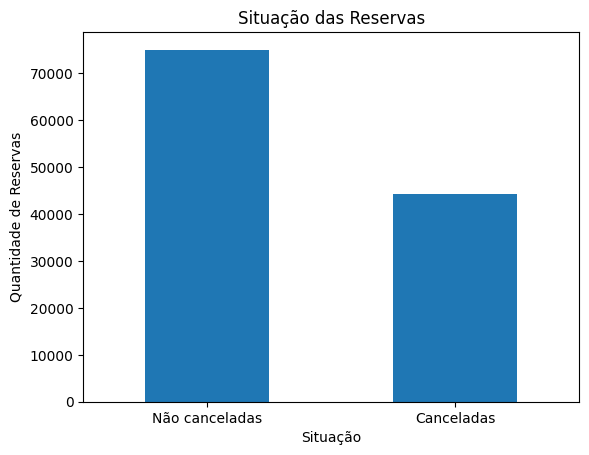

In [ ]:
import matplotlib.pyplot as plt

situacao_reservas = df_tratado['is_canceled'].value_counts().sort_index()

situacao_reservas.index = ['Não canceladas', 'Canceladas']

situacao_reservas.plot(kind='bar')

plt.title('Situação das Reservas')
plt.xlabel('Situação')
plt.ylabel('Quantidade de Reservas')
plt.xticks(rotation=0)
plt.show()

In [ ]:
resumo_hotel = df_tratado.groupby('hotel').agg(
    total_reservas=('is_canceled', 'count'),
    reservas_canceladas=('is_canceled', 'sum'),
    taxa_cancelamento=('is_canceled', 'mean')
)

resumo_hotel['taxa_cancelamento'] = (
    resumo_hotel['taxa_cancelamento'] * 100
).round(2)

resumo_hotel

,total_reservas,reservas_canceladas,taxa_cancelamento
hotel,,,
City Hotel,79163,33079,41.79
Resort Hotel,40046,11120,27.77


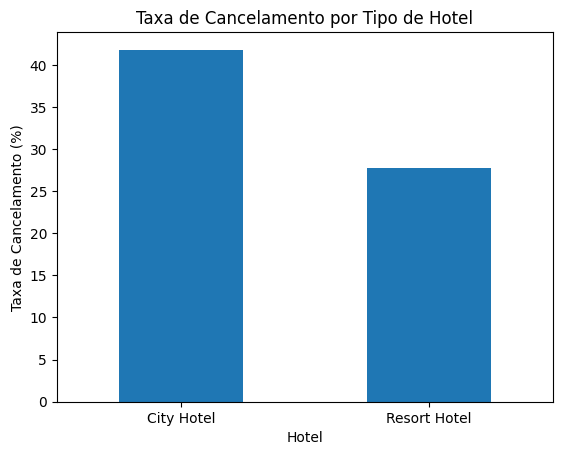

In [ ]:
resumo_hotel['taxa_cancelamento'].plot(kind='bar')

plt.title('Taxa de Cancelamento por Tipo de Hotel')
plt.xlabel('Hotel')
plt.ylabel('Taxa de Cancelamento (%)')
plt.xticks(rotation=0)
plt.show()

### Resumo

Os indicadores calculados fornecem uma visão geral do comportamento das
reservas e dos cancelamentos. Além dos indicadores gerais, foi realizada
uma comparação entre os tipos de hotel. Nas próximas etapas serão
investigadas as hipóteses relacionadas à antecedência das reservas e à
recorrência dos hóspedes.

## 12. Análise das Hipóteses
### 12.1 H1 – Antecedência da Reserva


### 12.2 H2 – Recorrência do Hóspede

## 13. Preparação dos Dados para Machine Learning


## 14. Separação dos Dados de Treino e Teste

## 15. Modelo Preditivo – Regressão Logística

## 16. Avaliação do Modelo

## 17. Interpretação dos Resultados


## 18. Exemplo de Predição

## 19. Conclusões